In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windfield import WindField
from tracer import solver, initial_velocity, fetch_wind_data

In [10]:
# shot input
shot_speed = 76.44384
shot_angle = 10.4	
shot_spin = 2545   	
P0 = [0,0,0]

log_wind = WindField(nx=300, ny=500, nz=100, direction=0, profile='log', z0=0.03)

# calculating shots
log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
log_W0 = np.array([0, -shot_spin, 0])
log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=0.01)

upper_bound = max(log_p[:,2])
lower_bound = 0

# calculating uniform U_ref from log
wind_collect = []
for i in range (round(upper_bound)):
    wind_collect.append(log_wind.get_point(0,0,i)['velocity'][0])
U_ref_uni = sum(wind_collect)/round(upper_bound)

uni_wind = WindField(nx=300, ny=500, nz=100, direction=0, profile='uniform', z0=0.01,U_ref=U_ref_uni)

uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
uni_W0 = np.array([0, -shot_spin, 0])
uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=0.01)

<function matplotlib.pyplot.show(close=None, block=None)>

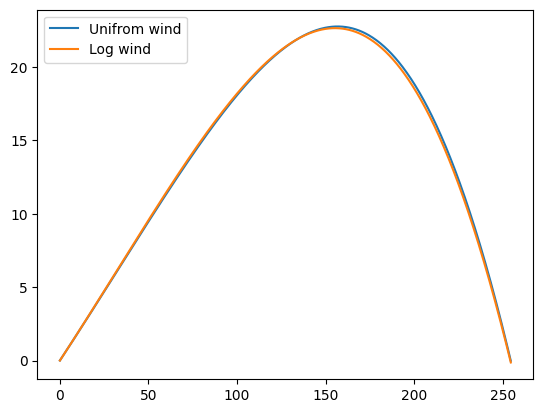

In [11]:
x = np.linspace(0,300)
plt.plot(uni_p[:,0],uni_p[:,2],label='Unifrom wind')
plt.plot(log_p[:,0],log_p[:,2],label='Log wind')
plt.legend()
plt.show

In [12]:
abs(uni_p[-1:,0]-log_p[-1:,0])

array([0.01190913])